In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

In [ ]:

PROJECT_ROOT = Path("..").resolve()

RESULTS_FOLDER = (
    PROJECT_ROOT
    / "Results"
)

EVALUATION_FOLDER = (
    RESULTS_FOLDER
    / "Evaluation"
)

EVALUATION_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Results folder:", RESULTS_FOLDER)
print("Evaluation folder:", EVALUATION_FOLDER)

Project root: C:\Users\srush\Desktop\Multi agent coordination
Results folder: C:\Users\srush\Desktop\Multi agent coordination\Results
Evaluation folder: C:\Users\srush\Desktop\Multi agent coordination\Results\Evaluation


In [ ]:

single_agent_path = (
    RESULTS_FOLDER
    / "single_agent_test_results.csv"
)

no_coordination_path = (
    RESULTS_FOLDER
    / "multi_agent_without_coordination_results.csv"
)

coordinated_path = (
    RESULTS_FOLDER
    / "coordinated_pipeline_test_results.csv"
)

ground_truth_path = (
    EVALUATION_FOLDER
    / "ground_truth_annotation_final.csv"
)


required_files = {
    "Single Agent results": single_agent_path,

    "Multi-Agent Without Coordination results":
        no_coordination_path,

    "Coordinated Multi-Agent results":
        coordinated_path,

    "Corrected ground truth":
        ground_truth_path
}


for file_name, file_path in required_files.items():

    print(
        file_name,
        "->",
        file_path
    )

    print(
        "Exists:",
        file_path.exists()
    )

    if not file_path.exists():

        raise FileNotFoundError(
            f"{file_name} was not found at: "
            f"{file_path}"
        )

    print()



Single Agent results -> C:\Users\srush\Desktop\Multi agent coordination\Results\single_agent_test_results.csv
Exists: True

Multi-Agent Without Coordination results -> C:\Users\srush\Desktop\Multi agent coordination\Results\multi_agent_without_coordination_results.csv
Exists: True

Coordinated Multi-Agent results -> C:\Users\srush\Desktop\Multi agent coordination\Results\coordinated_pipeline_test_results.csv
Exists: True

Corrected ground truth -> C:\Users\srush\Desktop\Multi agent coordination\Results\Evaluation\ground_truth_annotation_final.csv
Exists: True



In [4]:
single_df = pd.read_csv(
    single_agent_path
)

no_coord_df = pd.read_csv(
    no_coordination_path
)

coordinated_df = pd.read_csv(
    coordinated_path
)


print(
    "Single-agent rows:",
    len(single_df)
)

print(
    "No-coordination rows:",
    len(no_coord_df)
)

print(
    "Coordinated rows:",
    len(coordinated_df)
)

Single-agent rows: 15
No-coordination rows: 15
Coordinated rows: 15


In [ ]:


required_result_columns = {
    "test_id",
    "category",
    "user_query",
    "recommended_product",
    "recommended_asin",
    "top_5_asins",
    "top_5_titles",
    "total_latency",
    "error"
}


system_dataframes = {
    "Single Agent": single_df,

    "Multi-Agent Without Coordination":
        no_coord_df,

    "Coordinated Multi-Agent":
        coordinated_df
}


for system_name, dataframe in system_dataframes.items():

    missing_columns = (
        required_result_columns
        - set(dataframe.columns)
    )

    if missing_columns:

        raise ValueError(
            f"{system_name} is missing columns: "
            f"{missing_columns}"
        )

    print(
        system_name,
        "contains all required columns."
    )



Single Agent contains all required columns.
Multi-Agent Without Coordination contains all required columns.
Coordinated Multi-Agent contains all required columns.


In [ ]:


def normalise_asin(
    value
) -> str:

    if pd.isna(value):
        return ""

    return (
        str(value)
        .strip()
        .upper()
    )


def value_is_present(
    value
) -> bool:

    if pd.isna(value):
        return False

    cleaned = str(value).strip().lower()

    return cleaned not in {
        "",
        "none",
        "nan",
        "null"
    }


for dataframe in [
    single_df,
    no_coord_df,
    coordinated_df
]:

    dataframe["test_id"] = pd.to_numeric(
        dataframe["test_id"],
        errors="coerce"
    ).astype("Int64")

    dataframe["total_latency"] = pd.to_numeric(
        dataframe["total_latency"],
        errors="coerce"
    )

    dataframe["recommended_asin"] = (
        dataframe["recommended_asin"]
        .apply(normalise_asin)
    )

    dataframe["has_recommendation"] = (
        dataframe["recommended_asin"]
        .apply(value_is_present)
    )

    dataframe["has_error"] = (
        dataframe["error"]
        .apply(value_is_present)
    )


In [ ]:


single_df["system"] = (
    "Single Agent"
)

no_coord_df["system"] = (
    "Multi-Agent Without Coordination"
)

coordinated_df["system"] = (
    "Coordinated Multi-Agent"
)

In [ ]:


common_columns = [
    "test_id",
    "category",
    "user_query",
    "recommended_product",
    "recommended_asin",
    "top_5_asins",
    "top_5_titles",
    "total_latency",
    "error",
    "has_recommendation",
    "has_error",
    "system"
]


def keep_common_columns(
    dataframe: pd.DataFrame
) -> pd.DataFrame:

    cleaned = dataframe.copy()

    for column in common_columns:

        if column not in cleaned.columns:
            cleaned[column] = None

    return cleaned[
        common_columns
    ]


combined_results = pd.concat(
    [
        keep_common_columns(
            single_df
        ),

        keep_common_columns(
            no_coord_df
        ),

        keep_common_columns(
            coordinated_df
        )
    ],
    ignore_index=True
)


print(
    "Combined rows:",
    len(combined_results)
)

display(
    combined_results.head(15)
)



Combined rows: 45


,test_id,category,user_query,recommended_product,recommended_asin,top_5_asins,top_5_titles,total_latency,error,has_recommendation,has_error,system
0,1,Brand + Features,Recommend a Samsung phone with a good camera a...,Samsung Galaxy S22 Ultra 256GB Unlocked ATT TM...,B09X9FC88M,B09X9FC88M|B09S6VKCLX|B0BF1FZTLQ|B09WT8N5X7|B0...,Samsung Galaxy S22 Ultra 256GB Unlocked ATT TM...,6.4946,NaN,True,False,Single Agent
1,2,Brand + Features,I want an Apple phone with excellent camera qu...,Apple iPhone 7 - 256GB - GSM Unlocked - Red (R...,B078WZX9LD,B078WZX9LD|B00CX0OZHY|B00BUYRQG6,Apple iPhone 7 - 256GB - GSM Unlocked - Red (R...,3.4062,NaN,True,False,Single Agent
2,3,Brand + Features,Suggest a Google phone with fast performance.,Google Pixel 4a 5G UW Just Black-Verizon (Rene...,B09NP4C1MF,B09NP4C1MF|B08BXBT8MD|B01M27MVQI,Google Pixel 4a 5G UW Just Black-Verizon (Rene...,5.2435,NaN,True,False,Single Agent
3,4,Budget,Recommend a Samsung phone under 300 with a goo...,SAMSUNG Galaxy S9 G960U 64GB Unlocked GSM 4G L...,B07QH32PCY,B07QH32PCY|B00LMJDP1Y|B00CGIULGC,SAMSUNG Galaxy S9 G960U 64GB Unlocked GSM 4G L...,4.3800,NaN,True,False,Single Agent
4,5,Budget,Recommend a smartphone under 250 with long bat...,OUKITEL 8000mAh Large Battery 18W Flash Charge...,B0995SX8X8,B0995SX8X8|B01LZ8516T|B07B944RHF|B07RB4ZH83|B0...,OUKITEL 8000mAh Large Battery 18W Flash Charge...,6.5566,NaN,True,False,Single Agent
5,6,Feature Only,Recommend a phone with a great camera.,"ASUS ZenFone 3 MAX ZC520TL Smartphone, 5.2-inc...",B01LZ8516T,B01LZ8516T|B07QYTKZMT|B07F6ZM9QJ|B00ZAJB9C4|B0...,"ASUS ZenFone 3 MAX ZC520TL Smartphone, 5.2-inc...",5.5239,NaN,True,False,Single Agent
6,7,Feature Only,Recommend a phone with long battery life.,OUKITEL 8000mAh Large Battery 18W Flash Charge...,B0995SX8X8,B0995SX8X8|B01LZ8516T,OUKITEL 8000mAh Large Battery 18W Flash Charge...,4.0696,NaN,True,False,Single Agent
7,8,Feature Only,Suggest a smartphone for gaming.,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",B09L4QQCN2,B09L4QQCN2|B07F4BSXMQ,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",4.0306,NaN,True,False,Single Agent
8,9,Multiple Features,"Recommend a Samsung phone with a good camera, ...",Samsung Galaxy S22 Ultra 256GB Unlocked ATT TM...,B09X9FC88M,B09X9FC88M|B09S6VKCLX|B0BF1FZTLQ|B0B1QXHB7L|B0...,Samsung Galaxy S22 Ultra 256GB Unlocked ATT TM...,5.1046,NaN,True,False,Single Agent
9,10,Multiple Features,Recommend an Apple phone with a good camera an...,Apple iPhone 7 - 256GB - GSM Unlocked - Red (R...,B078WZX9LD,B078WZX9LD|B00CX0OZHY|B00BUYRQG6|B07DWFTVKL,Apple iPhone 7 - 256GB - GSM Unlocked - Red (R...,3.3782,NaN,True,False,Single Agent


In [ ]:


latency_summary = (
    combined_results
    .groupby(
        "system"
    )
    .agg(
        total_queries=(
            "test_id",
            "count"
        ),

        average_latency=(
            "total_latency",
            "mean"
        ),

        median_latency=(
            "total_latency",
            "median"
        ),

        minimum_latency=(
            "total_latency",
            "min"
        ),

        maximum_latency=(
            "total_latency",
            "max"
        ),

        standard_deviation=(
            "total_latency",
            "std"
        )
    )
    .reset_index()
)


latency_columns = [
    "average_latency",
    "median_latency",
    "minimum_latency",
    "maximum_latency",
    "standard_deviation"
]


latency_summary[
    latency_columns
] = latency_summary[
    latency_columns
].round(4)


display(
    latency_summary
)


,system,total_queries,average_latency,median_latency,minimum_latency,maximum_latency,standard_deviation
0,Coordinated Multi-Agent,15,9.8195,5.7380,3.1608,41.6571,12.1708
1,Multi-Agent Without Coordination,15,6.7467,5.1252,3.4809,12.4432,3.0613
2,Single Agent,15,4.7639,5.0078,1.8848,7.9947,1.6231


In [ ]:

availability_summary = (
    combined_results
    .groupby(
        "system"
    )
    .agg(
        total_queries=(
            "test_id",
            "count"
        ),

        recommendations_returned=(
            "has_recommendation",
            "sum"
        ),

        queries_with_errors=(
            "has_error",
            "sum"
        )
    )
    .reset_index()
)


availability_summary[
    "recommendation_rate"
] = (
    availability_summary[
        "recommendations_returned"
    ]
    / availability_summary[
        "total_queries"
    ]
)


availability_summary[
    "no_result_rate"
] = (
    1
    - availability_summary[
        "recommendation_rate"
    ]
)


availability_summary[
    "error_rate"
] = (
    availability_summary[
        "queries_with_errors"
    ]
    / availability_summary[
        "total_queries"
    ]
)


availability_summary[
    [
        "recommendation_rate",
        "no_result_rate",
        "error_rate"
    ]
] = availability_summary[
    [
        "recommendation_rate",
        "no_result_rate",
        "error_rate"
    ]
].round(4)


display(
    availability_summary
)

,system,total_queries,recommendations_returned,queries_with_errors,recommendation_rate,no_result_rate,error_rate
0,Coordinated Multi-Agent,15,11,0,0.7333,0.2667,0.0
1,Multi-Agent Without Coordination,15,15,0,1.0,0.0,0.0
2,Single Agent,15,13,0,0.8667,0.1333,0.0


In [ ]:

recommendation_comparison = (
    single_df[
        [
            "test_id",
            "category",
            "user_query",
            "recommended_product",
            "recommended_asin"
        ]
    ]
    .rename(
        columns={
            "recommended_product":
                "single_recommendation",

            "recommended_asin":
                "single_asin"
        }
    )
    .merge(
        no_coord_df[
            [
                "test_id",
                "recommended_product",
                "recommended_asin"
            ]
        ].rename(
            columns={
                "recommended_product":
                    "no_coord_recommendation",

                "recommended_asin":
                    "no_coord_asin"
            }
        ),
        on="test_id",
        how="outer"
    )
    .merge(
        coordinated_df[
            [
                "test_id",
                "recommended_product",
                "recommended_asin"
            ]
        ].rename(
            columns={
                "recommended_product":
                    "coordinated_recommendation",

                "recommended_asin":
                    "coordinated_asin"
            }
        ),
        on="test_id",
        how="outer"
    )
)


display(
    recommendation_comparison
)



,test_id,category,user_query,single_recommendation,single_asin,no_coord_recommendation,no_coord_asin,coordinated_recommendation,coordinated_asin
0,1,Brand + Features,Recommend a Samsung phone with a good camera a...,Samsung Galaxy S22 Ultra 256GB Unlocked ATT TM...,B09X9FC88M,"Samsung Galaxy S21 FE 5G Cell Phone, Factory U...",B0B1QXHB7L,"Samsung Galaxy S21 FE 5G Cell Phone, Factory U...",B0B1QXHB7L
1,2,Brand + Features,I want an Apple phone with excellent camera qu...,Apple iPhone 7 - 256GB - GSM Unlocked - Red (R...,B078WZX9LD,SteadyMate SM1 HD Professional Handheld Camera...,B00ORZVW42,SteadyMate SM1 HD Professional Handheld Camera...,B00ORZVW42
2,3,Brand + Features,Suggest a Google phone with fast performance.,Google Pixel 4a 5G UW Just Black-Verizon (Rene...,B09NP4C1MF,"Google Pixel XL 128GB - 5.5"" Android GSM 4G LT...",B01M27MVQI,NaN,
3,4,Budget,Recommend a Samsung phone under 300 with a goo...,SAMSUNG Galaxy S9 G960U 64GB Unlocked GSM 4G L...,B07QH32PCY,"Samsung Galaxy A52 (5G) 128GB A526U 6.5"" Displ...",B09C6N8P6Y,"Samsung Galaxy A52 (5G) 128GB A526U 6.5"" Displ...",B09C6N8P6Y
4,5,Budget,Recommend a smartphone under 250 with long bat...,OUKITEL 8000mAh Large Battery 18W Flash Charge...,B0995SX8X8,"KXD 6A | Unlocked Cell Phone | 5.5"" Full Scree...",B0B74J524C,NaN,
5,6,Feature Only,Recommend a phone with a great camera.,"ASUS ZenFone 3 MAX ZC520TL Smartphone, 5.2-inc...",B01LZ8516T,"POSH Revel S500a - 5.0"", 4G, Android 4.4 Kit K...",B00O3PAN1E,"POSH Revel S500a - 5.0"", 4G, Android 4.4 Kit K...",B00O3PAN1E
6,7,Feature Only,Recommend a phone with long battery life.,OUKITEL 8000mAh Large Battery 18W Flash Charge...,B0995SX8X8,"OUKITEL OK6000 Plus Unlocked Smartphones, 5.5i...",B07K9PR1H5,OUKITEL 8000mAh Large Battery 18W Flash Charge...,B0995SX8X8
7,8,Feature Only,Suggest a smartphone for gaming.,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",B09L4QQCN2,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",B09L4QQCN2,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",B09L4QQCN2
8,9,Multiple Features,"Recommend a Samsung phone with a good camera, ...",Samsung Galaxy S22 Ultra 256GB Unlocked ATT TM...,B09X9FC88M,Samsung Galaxy Mega 6.3 I9200 8GB Unlocked GSM...,B00D93LOY6,Samsung Galaxy Mega 6.3 I9200 8GB Unlocked GSM...,B00D93LOY6
9,10,Multiple Features,Recommend an Apple phone with a good camera an...,Apple iPhone 7 - 256GB - GSM Unlocked - Red (R...,B078WZX9LD,Apple iPhone 5 - 16GB (Black) Factory Unlocked,B00CX0OZHY,Apple iPhone 5 - 16GB (Black) Factory Unlocked,B00CX0OZHY


In [ ]:


def recommendations_match(
    first_asin,
    second_asin
) -> bool:

    first = normalise_asin(
        first_asin
    )

    second = normalise_asin(
        second_asin
    )

    if not first and not second:
        return True

    if not first or not second:
        return False

    return first == second


recommendation_comparison[
    "single_vs_no_coord_match"
] = recommendation_comparison.apply(
    lambda row: recommendations_match(
        row["single_asin"],
        row["no_coord_asin"]
    ),
    axis=1
)


recommendation_comparison[
    "single_vs_coordinated_match"
] = recommendation_comparison.apply(
    lambda row: recommendations_match(
        row["single_asin"],
        row["coordinated_asin"]
    ),
    axis=1
)


recommendation_comparison[
    "no_coord_vs_coordinated_match"
] = recommendation_comparison.apply(
    lambda row: recommendations_match(
        row["no_coord_asin"],
        row["coordinated_asin"]
    ),
    axis=1
)


agreement_summary = pd.DataFrame(
    {
        "comparison": [
            "Single vs No Coordination",
            "Single vs Coordinated",
            "No Coordination vs Coordinated"
        ],

        "agreement_rate": [
            recommendation_comparison[
                "single_vs_no_coord_match"
            ].mean(),

            recommendation_comparison[
                "single_vs_coordinated_match"
            ].mean(),

            recommendation_comparison[
                "no_coord_vs_coordinated_match"
            ].mean()
        ]
    }
)


agreement_summary[
    "agreement_rate"
] = agreement_summary[
    "agreement_rate"
].round(4)


display(
    agreement_summary
)


,comparison,agreement_rate
0,Single vs No Coordination,0.0667
1,Single vs Coordinated,0.2667
2,No Coordination vs Coordinated,0.6667


In [ ]:

category_summary = (
    combined_results
    .groupby(
        [
            "system",
            "category"
        ]
    )
    .agg(
        average_latency=(
            "total_latency",
            "mean"
        ),

        recommendation_rate=(
            "has_recommendation",
            "mean"
        ),

        total_queries=(
            "test_id",
            "count"
        )
    )
    .reset_index()
)


category_summary[
    [
        "average_latency",
        "recommendation_rate"
    ]
] = category_summary[
    [
        "average_latency",
        "recommendation_rate"
    ]
].round(4)


display(
    category_summary
)



,system,category,average_latency,recommendation_rate,total_queries
0,Coordinated Multi-Agent,Ambiguous,24.0360,1.0000,2
1,Coordinated Multi-Agent,Brand + Features,4.2970,0.6667,3
2,Coordinated Multi-Agent,Budget,23.5683,0.5000,2
3,Coordinated Multi-Agent,Feature Only,5.3301,1.0000,3
4,Coordinated Multi-Agent,Multiple Features,5.3533,1.0000,2
5,Coordinated Multi-Agent,Negative,3.3468,0.5000,2
6,Coordinated Multi-Agent,No Match,5.8018,0.0000,1
7,Multi-Agent Without Coordination,Ambiguous,8.8166,1.0000,2
8,Multi-Agent Without Coordination,Brand + Features,4.7409,1.0000,3
9,Multi-Agent Without Coordination,Budget,11.1733,1.0000,2


In [ ]:


print(
    "Loading ground truth from:",
    ground_truth_path
)


ground_truth = pd.read_csv(
    ground_truth_path
)


required_ground_truth_columns = {
    "test_id",
    "parent_asin",
    "is_relevant"
}


missing_ground_truth_columns = (
    required_ground_truth_columns
    - set(ground_truth.columns)
)


if missing_ground_truth_columns:

    raise ValueError(
        "Ground-truth file is missing columns: "
        f"{missing_ground_truth_columns}"
    )


display(
    ground_truth[
        [
            "test_id",
            "parent_asin",
            "is_relevant"
        ]
    ].head(20)
)

Loading ground truth from: C:\Users\srush\Desktop\Multi agent coordination\Results\Evaluation\ground_truth_annotation_final.csv


,test_id,parent_asin,is_relevant
0,1,B09X9FC88M,1
1,1,B0BM3F9RK1,1
2,1,B09S6VKCLX,1
3,1,B0BF1FZTLQ,1
4,1,B0B1QXHB7L,1
5,1,B09WT8N5X7,1
6,1,B07QH32PCY,1
7,2,B00CX0OZHY,0
8,2,B078WZX9LD,1
9,2,B00BUYRQG6,0


In [ ]:

ground_truth["test_id"] = pd.to_numeric(
    ground_truth["test_id"],
    errors="coerce"
).astype("Int64")


ground_truth["parent_asin"] = (
    ground_truth["parent_asin"]
    .apply(normalise_asin)
)


ground_truth["is_relevant"] = pd.to_numeric(
    ground_truth["is_relevant"],
    errors="coerce"
)


print(
    "Ground-truth label counts:"
)

print(
    ground_truth[
        "is_relevant"
    ].value_counts(
        dropna=False
    )
)


missing_labels = (
    ground_truth[
        "is_relevant"
    ]
    .isna()
    .sum()
)


if missing_labels > 0:

    raise ValueError(
        f"{missing_labels} rows have missing "
        "ground-truth relevance labels."
    )


invalid_labels = (
    set(
        ground_truth[
            "is_relevant"
        ].unique()
    )
    - {0, 1}
)


if invalid_labels:

    raise ValueError(
        "Invalid ground-truth labels found: "
        f"{invalid_labels}"
    )


ground_truth["is_relevant"] = (
    ground_truth["is_relevant"]
    .astype(int)
)


print(
    "Ground-truth labels are valid."
)



Ground-truth label counts:
is_relevant
0    43
1    39
Name: count, dtype: int64
Ground-truth labels are valid.


In [ ]:


relevant_lookup = (
    ground_truth[
        ground_truth[
            "is_relevant"
        ] == 1
    ]
    .groupby(
        "test_id"
    )[
        "parent_asin"
    ]
    .apply(set)
    .to_dict()
)


print(
    "Queries containing relevant products:",
    len(relevant_lookup)
)


for test_id, relevant_asins in (
    relevant_lookup.items()
):

    print(
        "Test",
        test_id,
        "->",
        relevant_asins
    )



Queries containing relevant products: 12
Test 1 -> {'B07QH32PCY', 'B09S6VKCLX', 'B0B1QXHB7L', 'B09X9FC88M', 'B0BF1FZTLQ', 'B09WT8N5X7', 'B0BM3F9RK1'}
Test 2 -> {'B078WZX9LD'}
Test 3 -> {'B08BXBT8MD', 'B01M27MVQI', 'B09NP4C1MF'}
Test 4 -> {'B0BM3F9RK1', 'B07QH32PCY'}
Test 5 -> {'B0995SX8X8', 'B01LZ8516T', 'B07RB4ZH83', 'B01N1WRJWA', 'B07K9PR1H5'}
Test 6 -> {'B09S6VKCLX', 'B08BXBT8MD', 'B01M27MVQI'}
Test 7 -> {'B0995SX8X8', 'B01LZ8516T'}
Test 8 -> {'B09L4QQCN2'}
Test 9 -> {'B09S6VKCLX', 'B0B1QXHB7L', 'B09X9FC88M', 'B0BF1FZTLQ', 'B09WT8N5X7', 'B0BM3F9RK1'}
Test 10 -> {'B078WZX9LD'}
Test 11 -> {'B09S6VKCLX', 'B0B1QXHB7L', 'B09X9FC88M', 'B09C6N8P6Y', 'B0BF1FZTLQ', 'B09WT8N5X7', 'B0BM3F9RK1'}
Test 14 -> {'B00JKSUHLU'}


In [ ]:


def split_asins(
    value
) -> list[str]:

    if pd.isna(value):
        return []

    value = str(value).strip()

    if not value:
        return []

    return [
        normalise_asin(
            asin
        )
        for asin in value.split("|")
        if normalise_asin(
            asin
        )
    ]



In [ ]:


overlap_rows = []


for system_name, dataframe in {
    "Single Agent": single_df,

    "Multi-Agent Without Coordination":
        no_coord_df,

    "Coordinated Multi-Agent":
        coordinated_df
}.items():

    total_matches = 0

    for _, row in dataframe.iterrows():

        test_id = int(
            row["test_id"]
        )

        predicted = set(
            split_asins(
                row[
                    "top_5_asins"
                ]
            )
        )

        relevant = relevant_lookup.get(
            test_id,
            set()
        )

        overlap = (
            predicted
            & relevant
        )

        total_matches += len(
            overlap
        )

        overlap_rows.append(
            {
                "system": system_name,
                "test_id": test_id,
                "predicted_count": len(
                    predicted
                ),
                "relevant_count": len(
                    relevant
                ),
                "matching_count": len(
                    overlap
                ),
                "matching_asins": "|".join(
                    sorted(
                        overlap
                    )
                )
            }
        )

    print(
        system_name,
        "total relevant matches:",
        total_matches
    )


overlap_df = pd.DataFrame(
    overlap_rows
)


display(
    overlap_df.head(20)
)



Single Agent total relevant matches: 27
Multi-Agent Without Coordination total relevant matches: 16
Coordinated Multi-Agent total relevant matches: 11


,system,test_id,predicted_count,relevant_count,matching_count,matching_asins
0,Single Agent,1,5,7,5,B07QH32PCY|B09S6VKCLX|B09WT8N5X7|B09X9FC88M|B0...
1,Single Agent,2,3,1,1,B078WZX9LD
2,Single Agent,3,3,3,3,B01M27MVQI|B08BXBT8MD|B09NP4C1MF
3,Single Agent,4,3,2,1,B07QH32PCY
4,Single Agent,5,5,5,4,B01LZ8516T|B01N1WRJWA|B07RB4ZH83|B0995SX8X8
5,Single Agent,6,5,3,0,
6,Single Agent,7,2,2,2,B01LZ8516T|B0995SX8X8
7,Single Agent,8,2,1,1,B09L4QQCN2
8,Single Agent,9,5,6,5,B09S6VKCLX|B09WT8N5X7|B09X9FC88M|B0B1QXHB7L|B0...
9,Single Agent,10,4,1,1,B078WZX9LD


In [ ]:


def precision_at_k(
    predicted: list[str],
    relevant: set[str],
    k: int = 5
) -> float:


    if not relevant:
        return np.nan

    predicted_k = predicted[:k]

    if not predicted_k:
        return 0.0

    hits = len(
        set(predicted_k)
        & relevant
    )

    return hits / k


def recall_at_k(
    predicted: list[str],
    relevant: set[str],
    k: int = 5
):

    # Recall is undefined when the query has no
    # relevant products in the annotated candidate pool.
    if not relevant:
        return np.nan

    predicted_k = set(
        predicted[:k]
    )

    hits = len(
        predicted_k
        & relevant
    )

    return (
        hits
        / len(
            relevant
        )
    )


In [ ]:


def evaluate_system(
    dataframe: pd.DataFrame,
    system_name: str
) -> pd.DataFrame:

    metric_rows = []

    for _, row in dataframe.iterrows():

        test_id = int(
            row["test_id"]
        )

        predicted = split_asins(
            row["top_5_asins"]
        )

        relevant = relevant_lookup.get(
            test_id,
            set()
        )

        precision = precision_at_k(
            predicted=predicted,
            relevant=relevant,
            k=5
        )

        recall = recall_at_k(
            predicted=predicted,
            relevant=relevant,
            k=5
        )

        no_relevant_products = (
            len(relevant) == 0
        )

        returned_no_result = (
            len(predicted) == 0
        )

        no_result_correct = (
            no_relevant_products
            and returned_no_result
        )

        metric_rows.append(
            {
                "system": system_name,
                "test_id": test_id,
                "category": row.get(
                    "category"
                ),
                "predicted_count": len(
                    predicted[:5]
                ),
                "relevant_count": len(
                    relevant
                ),
                "precision_at_5": precision,
                "recall_at_5": recall,
                "no_relevant_products": (
                    no_relevant_products
                ),
                "returned_no_result": (
                    returned_no_result
                ),
                "no_result_correct": (
                    no_result_correct
                )
            }
        )

    return pd.DataFrame(
        metric_rows
    )


In [ ]:


single_metrics = evaluate_system(
    dataframe=single_df,
    system_name="Single Agent"
)


no_coord_metrics = evaluate_system(
    dataframe=no_coord_df,
    system_name=(
        "Multi-Agent Without Coordination"
    )
)


coordinated_metrics = evaluate_system(
    dataframe=coordinated_df,
    system_name="Coordinated Multi-Agent"
)


all_metric_results = pd.concat(
    [
        single_metrics,
        no_coord_metrics,
        coordinated_metrics
    ],
    ignore_index=True
)


display(
    all_metric_results[
        [
            "system",
            "test_id",
            "precision_at_5",
            "recall_at_5",
            "no_result_correct"
        ]
    ]
)


,system,test_id,precision_at_5,recall_at_5,no_result_correct
0,Single Agent,1,1.0,0.714286,False
1,Single Agent,2,0.2,1.000000,False
2,Single Agent,3,0.6,1.000000,False
3,Single Agent,4,0.2,0.500000,False
4,Single Agent,5,0.8,0.800000,False
5,Single Agent,6,0.0,0.000000,False
6,Single Agent,7,0.4,1.000000,False
7,Single Agent,8,0.2,1.000000,False
8,Single Agent,9,1.0,0.833333,False
9,Single Agent,10,0.2,1.000000,False


In [ ]:

def get_test_row(
    dataframe: pd.DataFrame,
    test_id: int
) -> pd.Series:

    matched_rows = dataframe[
        dataframe["test_id"].astype(int) == test_id
    ]

    if matched_rows.empty:
        raise ValueError(
            f"Test ID {test_id} was not found."
        )

    return matched_rows.iloc[0]


def build_query_comparison(
    test_id: int
) -> pd.DataFrame:

    single_row = get_test_row(
        single_df,
        test_id
    )

    no_coord_row = get_test_row(
        no_coord_df,
        test_id
    )

    coordinated_row = get_test_row(
        coordinated_df,
        test_id
    )

    relevant_asins = relevant_lookup.get(
        test_id,
        set()
    )

    system_rows = [
        (
            "Single Agent",
            single_row
        ),
        (
            "Multi-Agent Without Coordination",
            no_coord_row
        ),
        (
            "Coordinated Multi-Agent",
            coordinated_row
        )
    ]

    comparison_rows = []

    for system_name, row in system_rows:

        top_asins = split_asins(
            row["top_5_asins"]
        )

        top_titles = []

        if pd.notna(
            row["top_5_titles"]
        ):

            top_titles = [
                title.strip()
                for title in str(
                    row["top_5_titles"]
                ).split("||")
                if title.strip()
            ]

        for rank in range(1, 6):

            asin = (
                top_asins[rank - 1]
                if rank - 1 < len(top_asins)
                else ""
            )

            title = (
                top_titles[rank - 1]
                if rank - 1 < len(top_titles)
                else ""
            )

            comparison_rows.append(
                {
                    "test_id": test_id,
                    "system": system_name,
                    "rank": rank,
                    "parent_asin": asin,
                    "product_title": title,
                    "is_relevant": (
                        1
                        if asin in relevant_asins
                        else 0
                    )
                }
            )

    comparison_df = pd.DataFrame(
        comparison_rows
    )

    return comparison_df

In [23]:
test_id_to_inspect = 8

query_comparison_df = build_query_comparison(
    test_id=test_id_to_inspect
)

query_text = single_df.loc[
    single_df["test_id"].astype(int)
    == test_id_to_inspect,
    "user_query"
].iloc[0]

print(
    "Test query:",
    query_text
)

print()

print(
    "Ground-truth relevant ASINs:"
)

print(
    relevant_lookup.get(
        test_id_to_inspect,
        set()
    )
)

display(
    query_comparison_df
)

Test query: Suggest a smartphone for gaming.

Ground-truth relevant ASINs:
{'B09L4QQCN2'}


,test_id,system,rank,parent_asin,product_title,is_relevant
0,8,Single Agent,1,B09L4QQCN2,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",1
1,8,Single Agent,2,B07F4BSXMQ,CUBOT Quest 5.5-inch Android 9.0 Pie Rugged Sm...,0
2,8,Single Agent,3,,,0
3,8,Single Agent,4,,,0
4,8,Single Agent,5,,,0
5,8,Multi-Agent Without Coordination,1,B09L4QQCN2,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",1
6,8,Multi-Agent Without Coordination,2,B0BLHCXZ8K,"SANSHREUNI Dual Sim Unlocked Cell Phones,4G+12...",0
7,8,Multi-Agent Without Coordination,3,B00O3PAN1E,"POSH Revel S500a - 5.0"", 4G, Android 4.4 Kit K...",0
8,8,Multi-Agent Without Coordination,4,B00NEEXCTK,Huawei Ascend G7 16GB GSM Unlocked Android Sma...,0
9,8,Multi-Agent Without Coordination,5,B00NO80S3E,"HTC Deluxe - 4G LTE GSM Factory Unlocked, 5"" A...",0


In [24]:
query_system_summary = (
    query_comparison_df
    .groupby(
        "system"
    )
    .agg(
        products_returned=(
            "parent_asin",
            lambda values: sum(
                bool(
                    str(value).strip()
                )
                for value in values
            )
        ),

        relevant_products_in_top_5=(
            "is_relevant",
            "sum"
        )
    )
    .reset_index()
)

query_system_summary[
    "precision_at_5"
] = (
    query_system_summary[
        "relevant_products_in_top_5"
    ]
    / 5
)

relevant_count = len(
    relevant_lookup.get(
        test_id_to_inspect,
        set()
    )
)

query_system_summary[
    "recall_at_5"
] = (
    query_system_summary[
        "relevant_products_in_top_5"
    ]
    / relevant_count
    if relevant_count > 0
    else np.nan
)

query_system_summary[
    [
        "precision_at_5",
        "recall_at_5"
    ]
] = query_system_summary[
    [
        "precision_at_5",
        "recall_at_5"
    ]
].round(4)

display(
    query_system_summary
)

,system,products_returned,relevant_products_in_top_5,precision_at_5,recall_at_5
0,Coordinated Multi-Agent,2,1,0.2,1.0
1,Multi-Agent Without Coordination,5,1,0.2,1.0
2,Single Agent,2,1,0.2,1.0


In [ ]:


if "verified_count" in coordinated_df.columns:

    coordinated_test_row = get_test_row(
        coordinated_df,
        test_id_to_inspect
    )

    print(
        "Coordinated ranked count:",
        coordinated_test_row.get(
            "ranked_count"
        )
    )

    print(
        "Coordinated verified count:",
        coordinated_test_row.get(
            "verified_count"
        )
    )

    print(
        "Coordinated verified Top-5 ASINs:",
        split_asins(
            coordinated_test_row[
                "top_5_asins"
            ]
        )
    )

Coordinated ranked count: 10
Coordinated verified count: 2
Coordinated verified Top-5 ASINs: ['B09L4QQCN2', 'B0BLHCXZ8K']


In [ ]:

evaluation_summary = (
    all_metric_results
    .groupby("system")
    .agg(
        total_test_queries=(
            "test_id",
            "count"
        ),

        ranking_queries=(
            "recall_at_5",
            "count"
        ),

        mean_precision_at_5=(
            "precision_at_5",
            "mean"
        ),

        median_precision_at_5=(
            "precision_at_5",
            "median"
        ),

        mean_recall_at_5=(
            "recall_at_5",
            "mean"
        ),

        median_recall_at_5=(
            "recall_at_5",
            "median"
        )
    )
    .reset_index()
)


evaluation_summary[
    [
        "mean_precision_at_5",
        "median_precision_at_5",
        "mean_recall_at_5",
        "median_recall_at_5"
    ]
] = evaluation_summary[
    [
        "mean_precision_at_5",
        "median_precision_at_5",
        "mean_recall_at_5",
        "median_recall_at_5"
    ]
].round(4)


display(
    evaluation_summary
)


,system,total_test_queries,ranking_queries,mean_precision_at_5,median_precision_at_5,mean_recall_at_5,median_recall_at_5
0,Coordinated Multi-Agent,15,12,0.1833,0.2,0.3143,0.1714
1,Multi-Agent Without Coordination,15,12,0.2667,0.2,0.4448,0.4643
2,Single Agent,15,12,0.4500,0.3,0.7016,0.8167


In [ ]:

no_result_rows = (
    all_metric_results[
        all_metric_results[
            "no_relevant_products"
        ]
    ]
)


if not no_result_rows.empty:

    no_result_summary = (
        no_result_rows
        .groupby(
            "system"
        )
        .agg(
            no_match_queries=(
                "test_id",
                "count"
            ),

            correctly_returned_no_result=(
                "no_result_correct",
                "sum"
            )
        )
        .reset_index()
    )

    no_result_summary[
        "no_result_accuracy"
    ] = (
        no_result_summary[
            "correctly_returned_no_result"
        ]
        / no_result_summary[
            "no_match_queries"
        ]
    )

    no_result_summary[
        "no_result_accuracy"
    ] = no_result_summary[
        "no_result_accuracy"
    ].round(4)

else:

    no_result_summary = pd.DataFrame(
        columns=[
            "system",
            "no_match_queries",
            "correctly_returned_no_result",
            "no_result_accuracy"
        ]
    )


display(
    no_result_summary
)


,system,no_match_queries,correctly_returned_no_result,no_result_accuracy
0,Coordinated Multi-Agent,3,2,0.6667
1,Multi-Agent Without Coordination,3,0,0.0000
2,Single Agent,3,2,0.6667


In [ ]:

category_metric_summary = (
    all_metric_results
    .groupby(
        [
            "system",
            "category"
        ]
    )
    .agg(
        mean_precision_at_5=(
            "precision_at_5",
            "mean"
        ),

        mean_recall_at_5=(
            "recall_at_5",
            "mean"
        ),

        query_count=(
            "test_id",
            "count"
        )
    )
    .reset_index()
)


category_metric_summary[
    [
        "mean_precision_at_5",
        "mean_recall_at_5"
    ]
] = category_metric_summary[
    [
        "mean_precision_at_5",
        "mean_recall_at_5"
    ]
].round(4)


display(
    category_metric_summary
)



,system,category,mean_precision_at_5,mean_recall_at_5,query_count
0,Coordinated Multi-Agent,Ambiguous,0.2000,0.1429,2
1,Coordinated Multi-Agent,Brand + Features,0.2000,0.1429,3
2,Coordinated Multi-Agent,Budget,0.1000,0.1000,2
3,Coordinated Multi-Agent,Feature Only,0.1333,0.5000,3
4,Coordinated Multi-Agent,Multiple Features,0.3000,0.2500,2
5,Coordinated Multi-Agent,Negative,0.2000,1.0000,2
6,Coordinated Multi-Agent,No Match,NaN,NaN,1
7,Multi-Agent Without Coordination,Ambiguous,0.2000,0.1429,2
8,Multi-Agent Without Coordination,Brand + Features,0.3333,0.3651,3
9,Multi-Agent Without Coordination,Budget,0.3000,0.3000,2


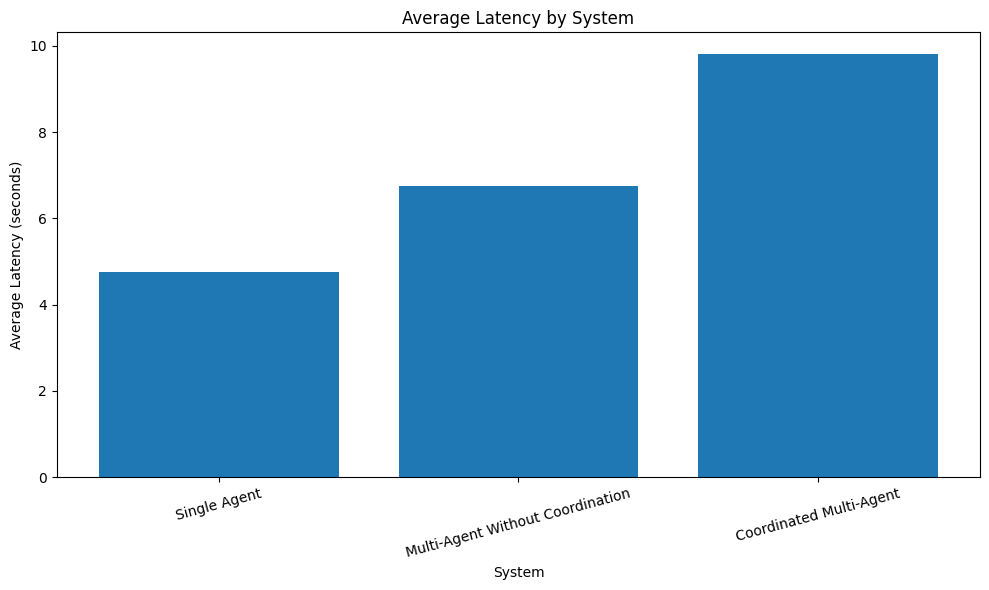

In [ ]:

latency_plot_data = (
    latency_summary
    .sort_values(
        "average_latency"
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.bar(
    latency_plot_data[
        "system"
    ],
    latency_plot_data[
        "average_latency"
    ]
)

plt.title(
    "Average Latency by System"
)

plt.xlabel(
    "System"
)

plt.ylabel(
    "Average Latency (seconds)"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    EVALUATION_FOLDER
    / "average_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



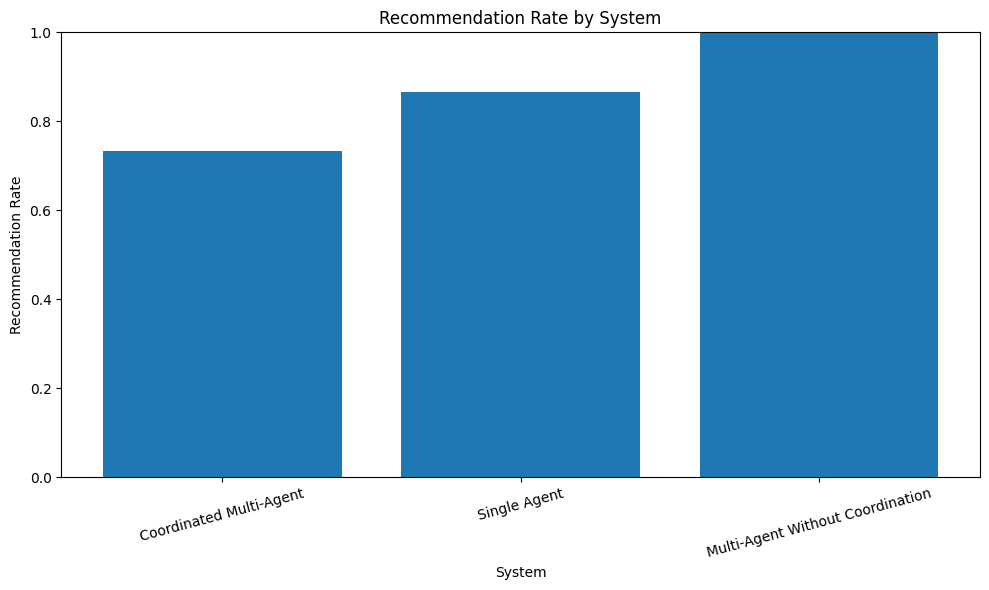

In [ ]:

recommendation_plot_data = (
    availability_summary
    .sort_values(
        "recommendation_rate"
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.bar(
    recommendation_plot_data[
        "system"
    ],
    recommendation_plot_data[
        "recommendation_rate"
    ]
)

plt.title(
    "Recommendation Rate by System"
)

plt.xlabel(
    "System"
)

plt.ylabel(
    "Recommendation Rate"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    EVALUATION_FOLDER
    / "recommendation_rate_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


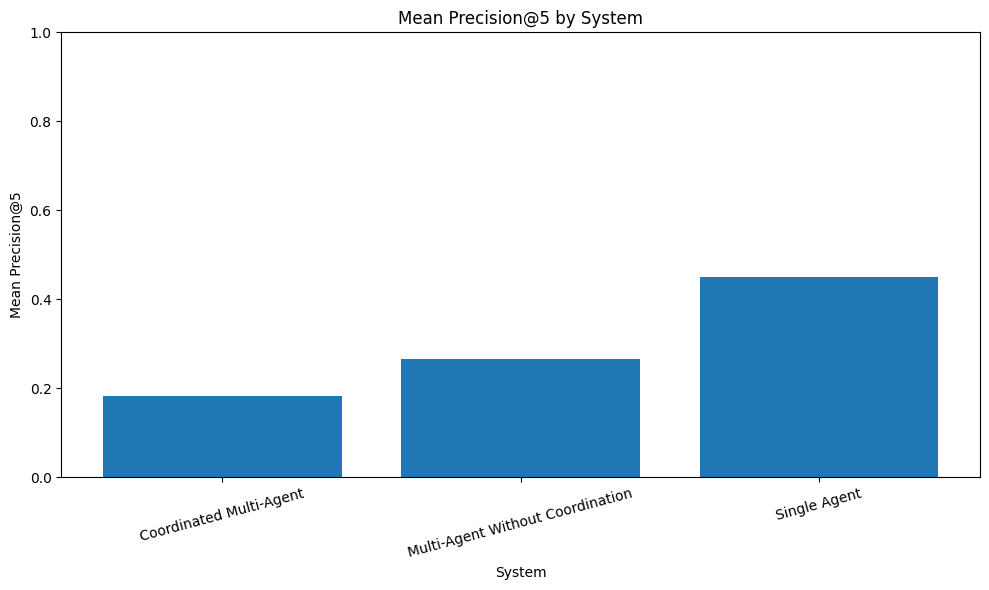

In [ ]:

precision_plot_data = (
    evaluation_summary
    .sort_values(
        "mean_precision_at_5"
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.bar(
    precision_plot_data[
        "system"
    ],
    precision_plot_data[
        "mean_precision_at_5"
    ]
)

plt.title(
    "Mean Precision@5 by System"
)

plt.xlabel(
    "System"
)

plt.ylabel(
    "Mean Precision@5"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    EVALUATION_FOLDER
    / "precision_at_5_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


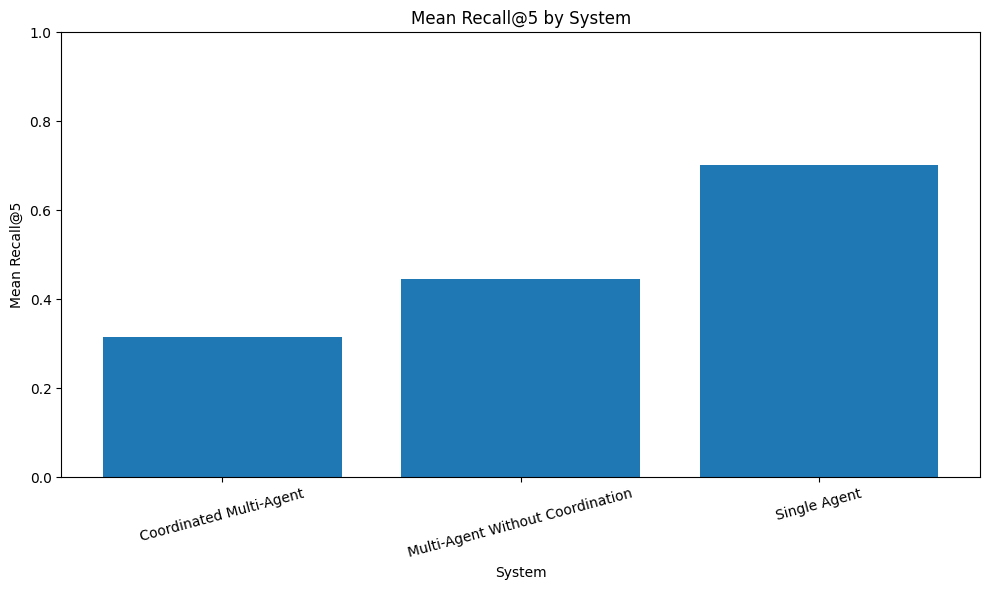

In [ ]:


recall_plot_data = (
    evaluation_summary
    .sort_values(
        "mean_recall_at_5"
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.bar(
    recall_plot_data[
        "system"
    ],
    recall_plot_data[
        "mean_recall_at_5"
    ]
)

plt.title(
    "Mean Recall@5 by System"
)

plt.xlabel(
    "System"
)

plt.ylabel(
    "Mean Recall@5"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.savefig(
    EVALUATION_FOLDER
    / "recall_at_5_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:


latency_summary.to_csv(
    EVALUATION_FOLDER
    / "latency_summary.csv",
    index=False
)


availability_summary.to_csv(
    EVALUATION_FOLDER
    / "availability_summary.csv",
    index=False
)


recommendation_comparison.to_csv(
    EVALUATION_FOLDER
    / "recommendation_comparison.csv",
    index=False
)


agreement_summary.to_csv(
    EVALUATION_FOLDER
    / "agreement_summary.csv",
    index=False
)


category_summary.to_csv(
    EVALUATION_FOLDER
    / "category_level_summary.csv",
    index=False
)


overlap_df.to_csv(
    EVALUATION_FOLDER
    / "asin_overlap_check.csv",
    index=False
)


all_metric_results.to_csv(
    EVALUATION_FOLDER
    / "query_level_metric_results.csv",
    index=False
)


evaluation_summary.to_csv(
    EVALUATION_FOLDER
    / "precision_recall_summary.csv",
    index=False
)


no_result_summary.to_csv(
    EVALUATION_FOLDER
    / "no_result_accuracy_summary.csv",
    index=False
)


category_metric_summary.to_csv(
    EVALUATION_FOLDER
    / "category_precision_recall_summary.csv",
    index=False
)


print(
    "All evaluation tables and charts were saved to:"
)

print(
    EVALUATION_FOLDER
)



All evaluation tables and charts were saved to:
C:\Users\srush\Desktop\Multi agent coordination\Results\Evaluation


In [ ]:


print()
print("=" * 100)
print("FINAL EVALUATION SUMMARY")
print("=" * 100)

display(
    evaluation_summary
)

print()
print("=" * 100)
print("LATENCY SUMMARY")
print("=" * 100)

display(
    latency_summary
)

print()
print("=" * 100)
print("NO-RESULT ACCURACY")
print("=" * 100)

display(
    no_result_summary
)


FINAL EVALUATION SUMMARY


,system,total_test_queries,ranking_queries,mean_precision_at_5,median_precision_at_5,mean_recall_at_5,median_recall_at_5
0,Coordinated Multi-Agent,15,12,0.1833,0.2,0.3143,0.1714
1,Multi-Agent Without Coordination,15,12,0.2667,0.2,0.4448,0.4643
2,Single Agent,15,12,0.4500,0.3,0.7016,0.8167



LATENCY SUMMARY


,system,total_queries,average_latency,median_latency,minimum_latency,maximum_latency,standard_deviation
0,Coordinated Multi-Agent,15,9.8195,5.7380,3.1608,41.6571,12.1708
1,Multi-Agent Without Coordination,15,6.7467,5.1252,3.4809,12.4432,3.0613
2,Single Agent,15,4.7639,5.0078,1.8848,7.9947,1.6231



NO-RESULT ACCURACY


,system,no_match_queries,correctly_returned_no_result,no_result_accuracy
0,Coordinated Multi-Agent,3,2,0.6667
1,Multi-Agent Without Coordination,3,0,0.0000
2,Single Agent,3,2,0.6667


### running test 8 


In [35]:
test_id_to_inspect = 8

query_comparison_df = build_query_comparison(
    test_id=test_id_to_inspect
)

query_text = single_df.loc[
    single_df["test_id"].astype(int)
    == test_id_to_inspect,
    "user_query"
].iloc[0]

print("Test query:", query_text)

print(
    "Ground-truth relevant ASINs:",
    relevant_lookup.get(
        test_id_to_inspect,
        set()
    )
)

display(query_comparison_df)

Test query: Suggest a smartphone for gaming.
Ground-truth relevant ASINs: {'B09L4QQCN2'}


,test_id,system,rank,parent_asin,product_title,is_relevant
0,8,Single Agent,1,B09L4QQCN2,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",1
1,8,Single Agent,2,B07F4BSXMQ,CUBOT Quest 5.5-inch Android 9.0 Pie Rugged Sm...,0
2,8,Single Agent,3,,,0
3,8,Single Agent,4,,,0
4,8,Single Agent,5,,,0
5,8,Multi-Agent Without Coordination,1,B09L4QQCN2,"Black Shark 4 Unlocked Phone, 5G Gaming Phone,...",1
6,8,Multi-Agent Without Coordination,2,B0BLHCXZ8K,"SANSHREUNI Dual Sim Unlocked Cell Phones,4G+12...",0
7,8,Multi-Agent Without Coordination,3,B00O3PAN1E,"POSH Revel S500a - 5.0"", 4G, Android 4.4 Kit K...",0
8,8,Multi-Agent Without Coordination,4,B00NEEXCTK,Huawei Ascend G7 16GB GSM Unlocked Android Sma...,0
9,8,Multi-Agent Without Coordination,5,B00NO80S3E,"HTC Deluxe - 4G LTE GSM Factory Unlocked, 5"" A...",0


In [ ]:

comparison_rows = []

test_ids = sorted(
    set(coordinated_df["test_id"].astype(int))
    & set(no_coord_df["test_id"].astype(int))
)

for test_id in test_ids:

    coord_row = coordinated_df[
        coordinated_df["test_id"].astype(int) == test_id
    ].iloc[0]

    no_coord_row = no_coord_df[
        no_coord_df["test_id"].astype(int) == test_id
    ].iloc[0]

    coord_asins = [
        x.strip()
        for x in str(
            coord_row.get("top_5_asins", "")
        ).split("|")
        if x.strip()
    ]

    no_coord_asins = [
        x.strip()
        for x in str(
            no_coord_row.get("top_5_asins", "")
        ).split("|")
        if x.strip()
    ]

    coord_set = set(coord_asins)
    no_coord_set = set(no_coord_asins)

    overlap = len(
        coord_set.intersection(no_coord_set)
    )

    comparison_rows.append(
        {
            "test_id": test_id,

            "user_query": coord_row.get(
                "user_query",
                ""
            ),

            "coordinated_top_5":
                " | ".join(coord_asins),

            "no_coord_top_5":
                " | ".join(no_coord_asins),

            "same_exact_order":
                coord_asins == no_coord_asins,

            "top_5_overlap":
                overlap,

            "overlap_percentage":
                round(
                    overlap / 5 * 100,
                    2
                )
        }
    )


coordination_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    coordination_comparison_df
)


print("\nSUMMARY")
print("=" * 60)

print(
    "Queries compared:",
    len(coordination_comparison_df)
)

print(
    "Exactly identical Top-5:",
    coordination_comparison_df[
        "same_exact_order"
    ].sum()
)

print(
    "Average Top-5 overlap:",
    round(
        coordination_comparison_df[
            "overlap_percentage"
        ].mean(),
        2
    ),
    "%"
)

,test_id,user_query,coordinated_top_5,no_coord_top_5,same_exact_order,top_5_overlap,overlap_percentage
0,1,Recommend a Samsung phone with a good camera a...,B0B1QXHB7L | B09S6VKCLX | B09WT8N5X7 | B00D93L...,B0B1QXHB7L | B09S6VKCLX | B09WT8N5X7 | B00D93L...,True,5,100.0
1,2,I want an Apple phone with excellent camera qu...,B00ORZVW42,B00ORZVW42,True,1,20.0
2,3,Suggest a Google phone with fast performance.,nan,B01M27MVQI | B08BXBT8MD,False,0,0.0
3,4,Recommend a Samsung phone under 300 with a goo...,B09C6N8P6Y | B00CGIULGC | B0B1QXHB7L | B00D93L...,B09C6N8P6Y | B00CGIULGC | B0B1QXHB7L | B00D93L...,True,5,100.0
4,5,Recommend a smartphone under 250 with long bat...,B0995SX8X8 | B0BBRBXPGC,B0B74J524C | B07K9PR1H5 | B0995SX8X8 | B09L4QQ...,False,1,20.0
5,6,Recommend a phone with a great camera.,B00O3PAN1E | B00NEEXCTK | B00CGIULGC | B002VRO...,B00O3PAN1E | B00NEEXCTK | B00CGIULGC | B002VRO...,True,5,100.0
6,7,Recommend a phone with long battery life.,B0995SX8X8 | B0BBRBXPGC,B07K9PR1H5 | B0995SX8X8 | B09L4QQCN2 | B01LZ85...,False,1,20.0
7,8,Suggest a smartphone for gaming.,B09L4QQCN2 | B0BLHCXZ8K,B09L4QQCN2 | B0BLHCXZ8K | B00O3PAN1E | B00NEEX...,False,2,40.0
8,9,"Recommend a Samsung phone with a good camera, ...",B00D93LOY6 | B00JKSUHLU | B0B1QXHB7L | B09S6VK...,B00D93LOY6 | B00JKSUHLU | B0B1QXHB7L | B09S6VK...,True,5,100.0
9,10,Recommend an Apple phone with a good camera an...,B00CX0OZHY | B00BUYRQG6 | B00ORZVW42,B00CX0OZHY | B00BUYRQG6 | B00ORZVW42,True,3,60.0



SUMMARY
Queries compared: 15
Exactly identical Top-5: 9
Average Top-5 overlap: 57.33 %
